In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from rich.progress import track
from rich.table import Table
from rich.console import Console
import numpy as np

In [2]:
X_train = pd.read_csv("./data/TinyMNIST/trainData.csv", header=None)
X_test = pd.read_csv("./data/TinyMNIST/testData.csv", header=None)
y_train = pd.read_csv("./data/TinyMNIST/trainLabels.csv", header=None)
y_test = pd.read_csv("./data/TinyMNIST/testLabels.csv", header=None)
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,193,194,195
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.118627,0.067647,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [3]:
y_train.head()

,0
0,7.0
1,3.0
2,4.0
3,6.0
4,1.0


In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5000, 196)
(2500, 196)
(5000, 1)
(2500, 1)


In [5]:
def ccr(y_true, y_pred):
    return (y_true == y_pred).mean()

In [6]:
def forward_selection(max_feature_count: int = None) -> tuple[list[float], list[str]]:
    model = MultinomialNB()
    selected_features = []
    forward_selection_scores = []
    if max_feature_count is None:
        max_feature_count = X_train.shape[1]
    for i in track(range(max_feature_count)):
        best_feature = None
        best_score = 0
        for j in range(X_train.shape[1]):
            if j in selected_features:
                continue
            features_to_test = selected_features + [j]
            model.fit(X_train.iloc[:, features_to_test], y_train.iloc[:, 0])
            y_pred = model.predict(X_test.iloc[:, features_to_test])
            score = ccr(y_test.iloc[:, 0], y_pred)
            if score > best_score:
                best_score = score
                best_feature = j
        selected_features.append(best_feature)
        forward_selection_scores.append(best_score)
    return forward_selection_scores, selected_features

In [7]:
# forward selection
forward_selection_scores, _ = forward_selection()

Output()

In [8]:
def backward_elimination(
    min_feature_count: int = None,
) -> tuple[list[float], list[str]]:
    model = MultinomialNB()
    selected_features = list(range(X_train.shape[1]))
    backward_elimination_scores = []
    if min_feature_count is None:
        min_feature_count = 1
    for i in track(range(X_train.shape[1], min_feature_count, -1)):
        best_feature = None
        best_score = 0
        for j in range(X_train.shape[1]):
            if j not in selected_features:
                continue
            features_to_test = [f for f in selected_features if f != j]
            model.fit(X_train.iloc[:, features_to_test], y_train.iloc[:, 0])
            y_pred = model.predict(X_test.iloc[:, features_to_test])
            score = ccr(y_test.iloc[:, 0], y_pred)
            if score > best_score:
                best_score = score
                best_feature = j
        selected_features.remove(best_feature)
        backward_elimination_scores.append(best_score)
    return backward_elimination_scores, selected_features

In [9]:
backward_elimination_scores, _ = backward_elimination()

Output()

In [10]:
print("Forward selection best score:", np.max(forward_selection_scores))
print("Forward selecton feature count", np.argmax(forward_selection_scores) + 1)
print("Backward elimination best score", np.max(backward_elimination_scores))
print(
    "Backward elimination feature count",
    X_train.shape[1] - np.argmax(backward_elimination_scores) - 1,
)

Forward selection best score: 0.8152
Forward selecton feature count 127
Backward elimination best score 0.8148
Backward elimination feature count 79


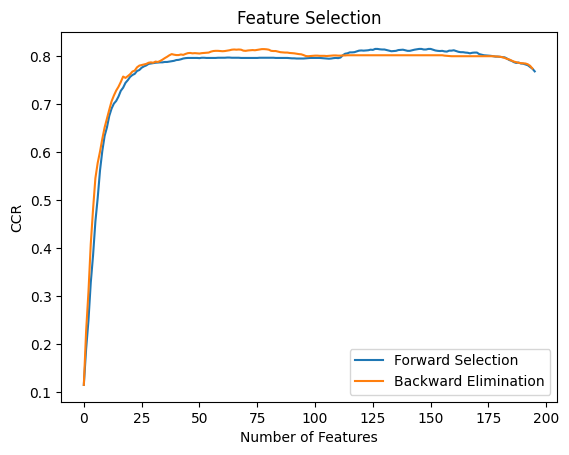

In [11]:
plt.plot(forward_selection_scores, label="Forward Selection")
plt.plot(list(reversed(backward_elimination_scores)), label="Backward Elimination")
plt.xlabel("Number of Features")
plt.ylabel("CCR")
plt.title("Feature Selection")
plt.legend()
plt.show()

In [26]:
_, forward_selected_features = forward_selection(75)
_, backward_selected_features = backward_elimination(75)
forward_selected_features.sort()
backward_elimination_scores.sort()

Output()

Output()

In [23]:
def compress(data: list[int]) -> list[str]:
    ranges = []
    start = data[0]
    end = data[0]
    for i in range(1, len(data)):
        if data[i] == end + 1:
            end = data[i]
        else:
            if start == end:
                ranges.append(f"{start}")
            else:
                ranges.append(f"{start}-{end}")
            start = data[i]
            end = data[i]
    if start == end:
        ranges.append(f"{start}")
    else:
        ranges.append(f"{start}-{end}")
    return ranges

In [30]:
assert len(forward_selected_features) == len(backward_selected_features)
table = Table(title="Selected Features Comparison")
table.add_column("#")
table.add_column("Forward Selection Features", justify="center")
table.add_column("Backward Elimination Features", justify="center")
compressed_forward_selected_features = compress(forward_selected_features)
compressed_backward_selected_features = compress(backward_selected_features)
for i in range(
    max(
        len(compressed_forward_selected_features),
        len(compressed_backward_selected_features),
    )
):
    f_feat = (
        compressed_forward_selected_features[i]
        if i < len(compressed_forward_selected_features)
        else ""
    )
    b_feat = (
        compressed_backward_selected_features[i]
        if i < len(compressed_backward_selected_features)
        else ""
    )
    table.add_row(str(i + 1), str(f_feat), str(b_feat))
    # print(str(f_feat), str(b_feat), sep = '&', end = '\\\\\n')
console = Console()
console.print(table)

                   Selected Features Comparison                    
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ #  ┃ Forward Selection Features ┃ Backward Elimination Features ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1  │            0-19            │              20               │
│ 2  │             21             │              23               │
│ 3  │           23-29            │              33               │
│ 4  │             33             │             35-37             │
│ 5  │             36             │             45-46             │
│ 6  │           41-42            │             48-50             │
│ 7  │             44             │             52-53             │
│ 8  │           48-49            │              58               │
│ 9  │             52             │             60-66             │
│ 10 │           54-55            │              68               │
│ 11 │             58             │             73-79             │
│ 12 │             63             │             87-93             │
│ 13 │             69             │            102-109            │
│ 14 │           74-75            │              116              │
│ 15 │           78-79            │            118-120            │
│ 16 │             83             │              123              │
│ 17 │           90-91            │            130-134            │
│ 18 │           96-97            │              136              │
│ 19 │             99             │              138              │
│ 20 │            102             │            142-143            │
│ 21 │            104             │            145-151            │
│ 22 │            106             │            156-157            │
│ 23 │            109             │            161-162            │
│ 24 │            113             │              164              │
│ 25 │            119             │            172-174            │
│ 26 │            121             │              186              │
│ 27 │          124-125           │              189              │
│ 28 │            131             │                               │
│ 29 │            138             │                               │
│ 30 │            141             │                               │
│ 31 │          144-145           │                               │
│ 32 │            152             │                               │
│ 33 │            160             │                               │
│ 34 │            164             │                               │
│ 35 │            166             │                               │
│ 36 │          171-172           │                               │
│ 37 │          178-180           │                               │
│ 38 │            193             │                               │
└────┴────────────────────────────┴───────────────────────────────┘

In [31]:
model = MultinomialNB()

model.fit(X_train.iloc[:, forward_selected_features], y_train.iloc[:, 0])
y_pred = model.predict(X_test.iloc[:, forward_selected_features])
score = ccr(y_test.iloc[:, 0], y_pred)
print("CCR with selected features from Forward Selection:", score)

model.fit(X_train.iloc[:, backward_selected_features], y_train.iloc[:, 0])
y_pred = model.predict(X_test.iloc[:, backward_selected_features])
score = ccr(y_test.iloc[:, 0], y_pred)
print("CCR with selected features from Backward Elimination:", score)

CCR with selected features from Forward Selection: 0.7964
CCR with selected features from Backward Elimination: 0.8124
